# DigiChrom ML Pipeline
**Predicting electrochemical chromium layer thickness from process parameters**

---
| Section | Content |
|---|---|
| 0 | Setup & Imports |
| 1 | Data Loading |
| 2 | Exploration |
| 3 | Preprocessing (incl. binary labels) |
| **4** | **Regression** |
| 4a | · Model Testing — CV |
| 4b | · HP Tuning (orig + aug) |
| 4c | · Ensemble — top-3 HPO models |
| 4d | · Final Training + best_predictor |
| 4e | · XAI (single model) |
| **5** | **Classification** |
| 5a | · Model Testing — CV |
| 5b | · HP Tuning (orig + aug) |
| 5c | · Ensemble — top-3 HPO classifiers |
| 5d | · Final Training + best_predictor |
| 5e | · XAI (single model) |
| 6 | Inverse ML (single regression model) |
| 7 | Comprehensive Report |

## 0 · Setup & Config

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# !pip install optuna catboost xgboost lightgbm pytorch-tabnet

In [26]:
import sys
import json as _json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# make pipeline/ importable
ROOT = Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# pipeline importable for colab
# if 'google.colab' in sys.modules:
#     ROOT = Path('/content/drive/MyDrive/work/PhD/digichrom_HS_Aalen/DigiChrom_Pipeline')
# if str(ROOT) not in sys.path:
#     sys.path.insert(0, str(ROOT))
#     print(f"Added {ROOT} to sys.path")

import config_TU_Ilmenau as config
from pipeline import config as pipeline_config
pipeline_config.set_config(config)

from pipeline import data_loading, exploration, preprocessing, model_testing
from pipeline import hp_tuning, xai, inverse_ml
from pipeline.ensemble import (
    AveragingEnsemble, WeightedEnsemble, StackingEnsemble,
)
from pipeline.final_training import _build_model, _build_classifier
from pipeline.preprocessing import make_preprocessor
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, confusion_matrix,
)

print(f'Target        : {config.TARGET_COL}')
print(f'Features      : {len(config.FEATURE_COLS)}')
print(f'CV Folds      : {config.CV_FOLDS}')

Target        : Thickness Cr [µm]
Features      : 20
CV Folds      : 5


## 1 · Data Loading

In [3]:
df, quality_report = data_loading.load_clean()

print(f"Shape: {df.shape}")
print(f"\nData quality report:")
for k, v in quality_report.items():
    print(f"  {k}: {v}")

[data_loading] 441 rows loaded, 0 dropped → 441 clean rows
Shape: (441, 21)

Data quality report:
  total_rows: 441
  rows_with_nan: 0
  rows_after_drop: 441
  missing_columns: []
  nan_per_feature: {}


In [4]:
display(df.describe().round(2))

,pH,Deposition time [min],Temperature [°C],Current density [A/dm²],Chromium [g/L],Buffer [g/L],Complexing agent [mL/L],Additive [mL/L],Supporting electrolyte [g/L],Brigthener [mL/L],...,Iron [mg/L],Copper [mg/L],Bath age [Ah/L],Last reactivation [days],Service life [days],Gloss Nickel layer [%],Sample Area [dm²],Anode Area [dm²],Volume [L],Thickness Cr [µm]
count,441.00,441.00,441.00,441.00,441.00,441.00,441.00,441.00,441.00,441.00,...,441.00,441.00,441.00,441.00,441.00,441.00,441.00,441.00,441.00,441.00
mean,3.44,9.16,55.19,7.05,10.26,89.91,39.64,22.65,175.21,2.53,...,2.63,3.02,7.93,33.35,4.13,0.76,1.11,2.26,11.79,0.31
std,0.18,4.08,3.23,2.09,0.31,2.47,1.81,3.67,0.56,0.51,...,4.34,2.81,7.05,26.91,5.02,0.29,0.19,2.44,5.04,0.20
min,3.00,1.00,50.00,2.80,9.59,69.57,37.06,15.46,174.35,1.20,...,0.00,0.15,0.00,0.00,0.00,0.00,0.71,0.84,1.00,0.01
25%,3.40,7.65,52.00,5.94,10.15,89.88,40.00,19.94,174.94,2.38,...,0.71,0.47,2.67,10.00,1.00,0.69,1.20,0.84,14.14,0.17
50%,3.40,8.00,55.00,7.00,10.34,89.96,40.00,21.86,174.98,2.46,...,1.64,1.78,5.67,30.00,3.00,0.90,1.20,0.84,14.14,0.27
75%,3.60,12.15,57.60,8.13,10.44,90.00,40.00,24.32,175.00,2.50,...,2.76,5.04,9.59,49.00,6.00,0.95,1.20,6.44,14.14,0.41
max,3.70,20.00,60.00,11.60,11.51,92.87,50.00,30.30,176.43,5.37,...,46.56,8.36,30.90,96.00,41.00,1.00,1.20,6.44,14.14,1.37


## 2 · Exploration

[exploration] Saved correlation matrix → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/correlation_matrix.pdf


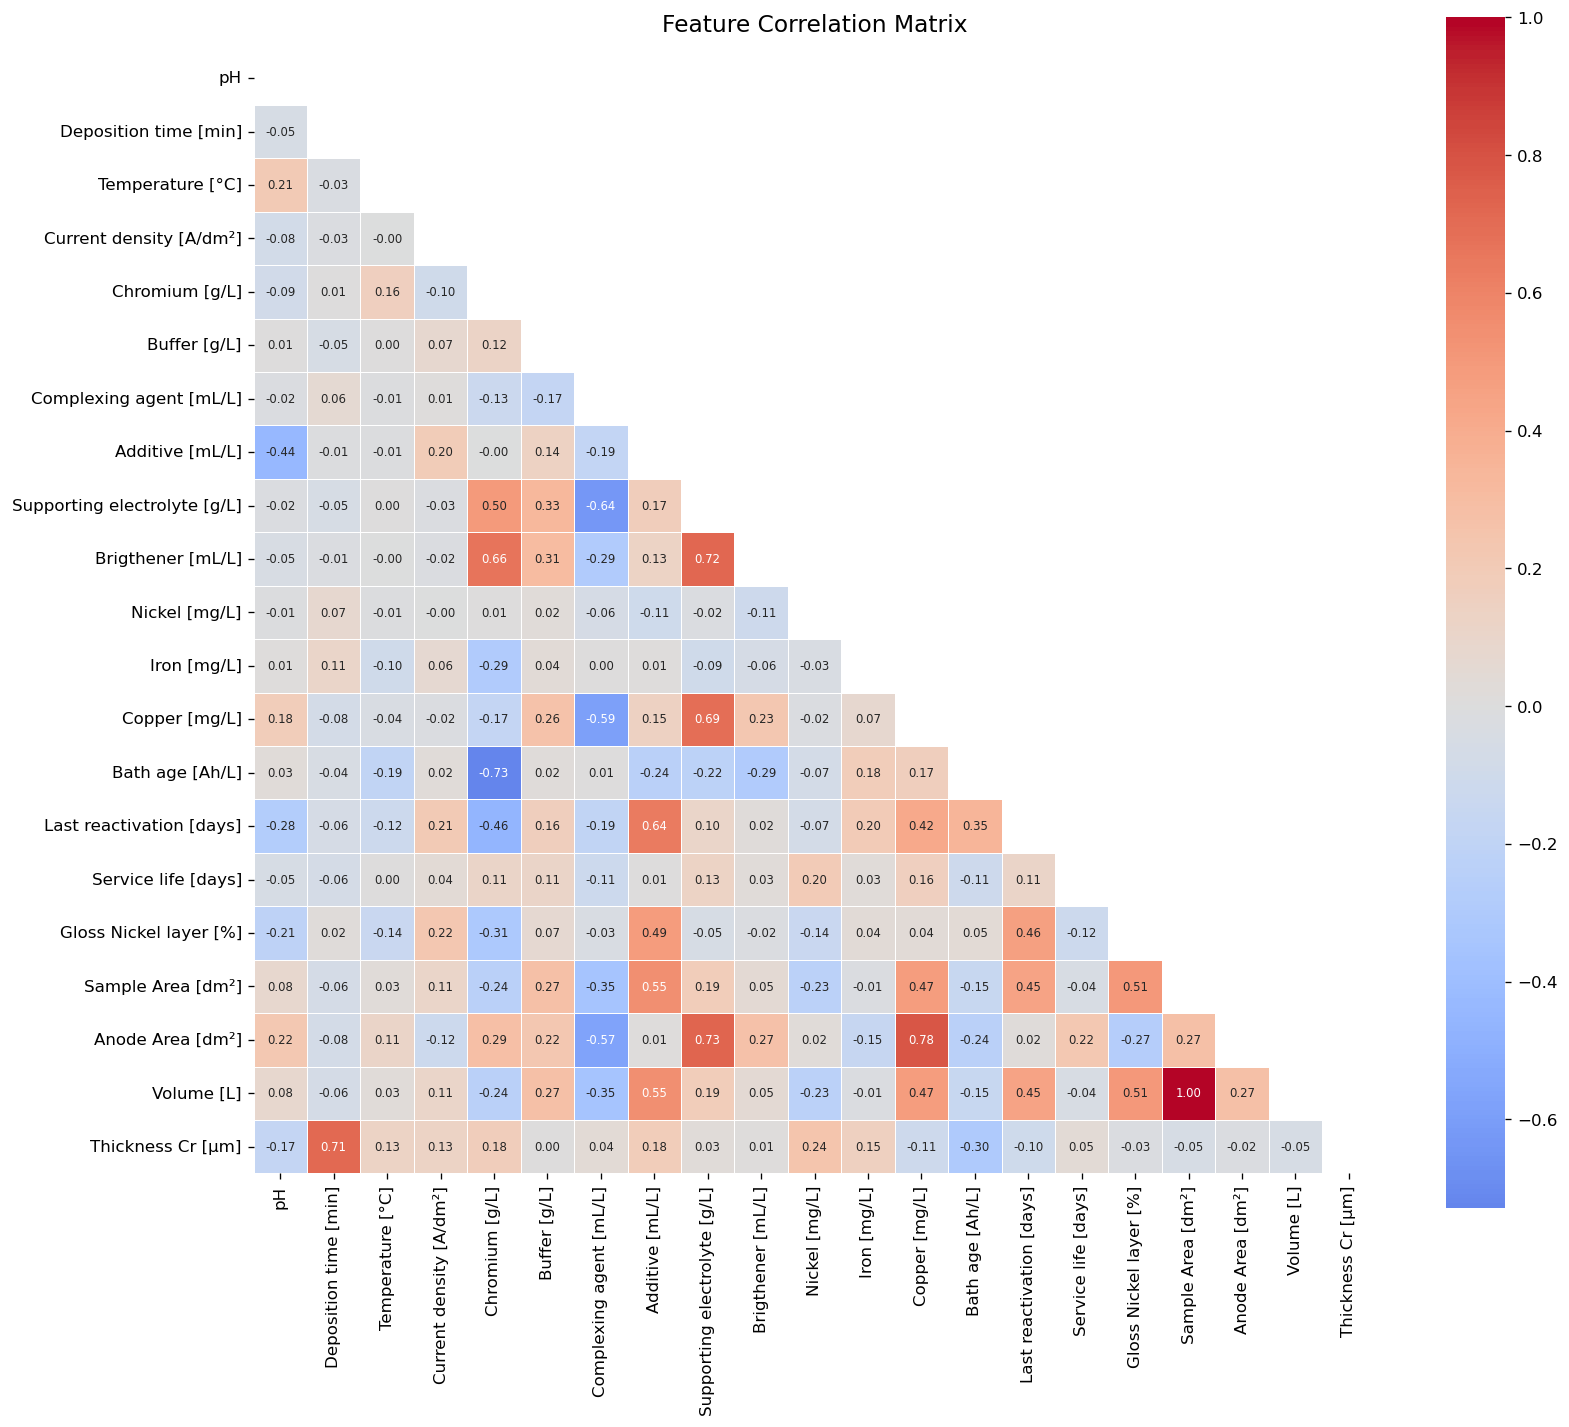

In [5]:
exploration.correlation_matrix(df)

[exploration] Saved distributions → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/feature_distributions.pdf


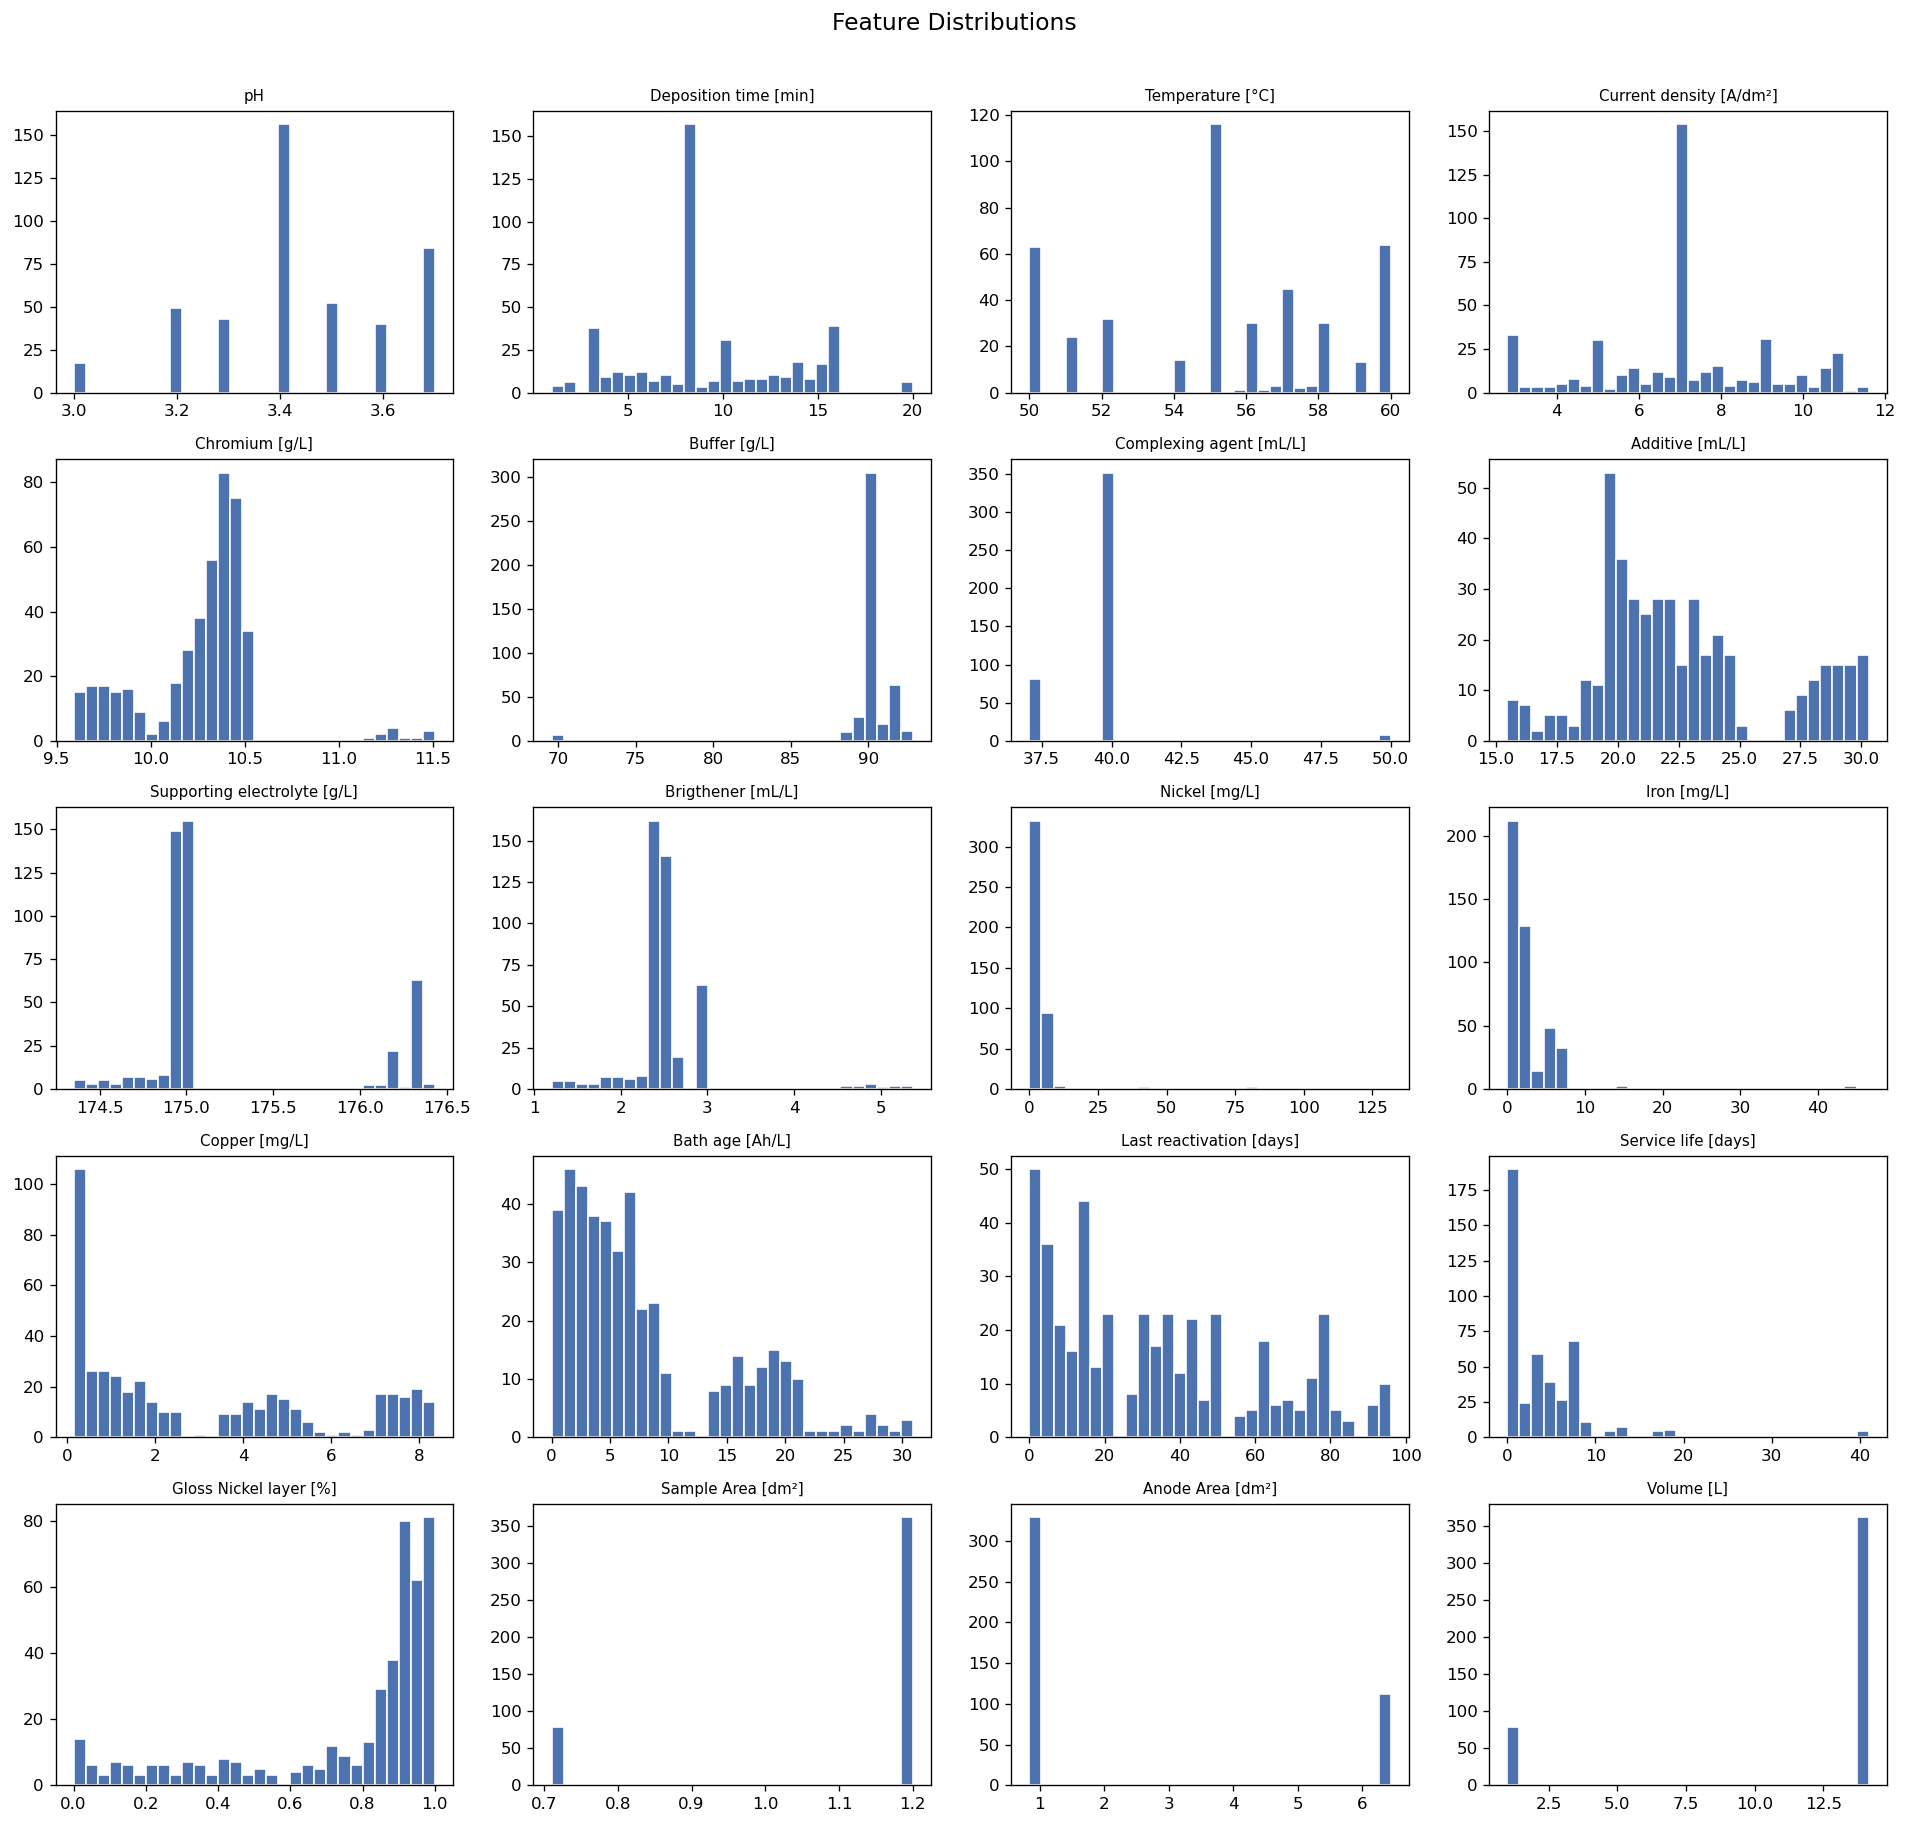

In [6]:
exploration.feature_distributions(df)

[exploration] Saved target vs features → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/target_vs_features.pdf


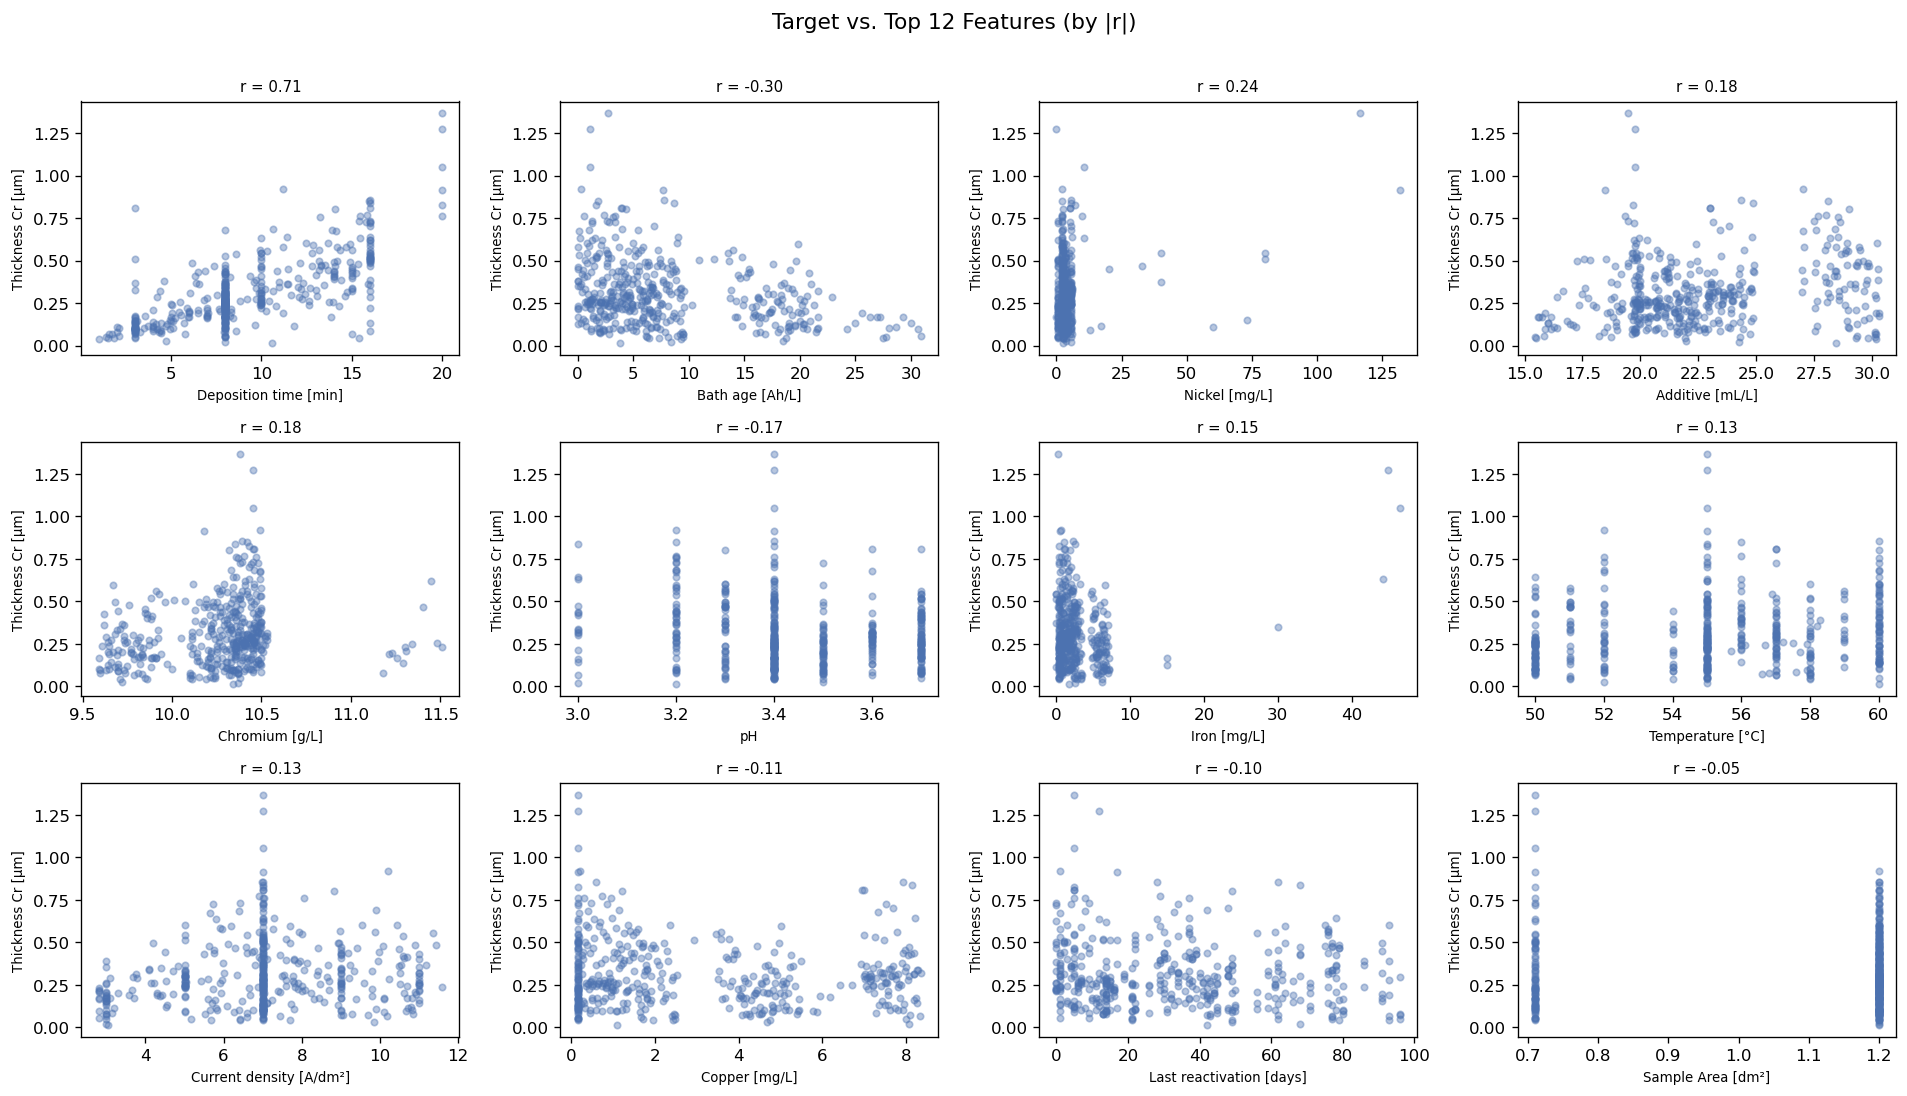

In [7]:
exploration.target_vs_features(df)

## 3 · Preprocessing

In [8]:
X, y = preprocessing.split_xy(df)
X_train, X_test, y_train, y_test = preprocessing.train_test(X, y)
cv_splits = preprocessing.cross_val_splits(X_train, y_train)
BOUNDS = preprocessing.feature_bounds(X_train)
feature_names = list(X_train.columns)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'CV: {len(cv_splits)} folds')

# Binary labels for classification (used throughout Section 5)
median_threshold = float(y_train.median())
y_train_cls = (y_train >= median_threshold).astype(int)
y_test_cls  = (y_test  >= median_threshold).astype(int)
print(f'\nClassification threshold (median): {median_threshold:.4f} µm')
print(f'Train class dist: {y_train_cls.value_counts().to_dict()}  (0=thin, 1=thick)')
print(f'Test  class dist: {y_test_cls.value_counts().to_dict()}')

Train: (374, 20), Test: (67, 20)
CV: 5 folds

Classification threshold (median): 0.2654 µm
Train class dist: {0: 187, 1: 187}  (0=thin, 1=thick)
Test  class dist: {1: 37, 0: 30}


## 4 · Regression

### 4a · Model Testing — Cross-Validation

In [ ]:
cv_results_path = config.REPORTS_DIR / 'cv_results_reg.csv'
if cv_results_path.exists():
    cv_results = pd.read_csv(cv_results_path)
    print(f"Loaded CV results from {cv_results_path}")
else:
    models = model_testing.get_models()
    print(f'Models: {list(models.keys())}')

    cv_results = model_testing.evaluate_all(
        X_train, y_train,
        models=models,
        cv_splits=cv_splits
    )
    cv_results.to_csv(config.REPORTS_DIR / 'cv_results_reg.csv', index=False)

    cv_summary = cv_results.groupby('model')[['r2','rmse','mae']].agg(['mean','std']).round(3)
    display(cv_summary.sort_values(('r2','mean'), ascending=False))

Models: ['linear', 'ridge', 'elasticnet', 'cart', 'gradient_boosting', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'catboost', 'lightgbm', 'mlp', 'tab_cnn', 'ft_transformer', 'saint', 'deep_gbm', 'tabnet']
[model_testing] Evaluating linear (5 folds)...
[model_testing] Evaluating ridge (5 folds)...
[model_testing] Evaluating elasticnet (5 folds)...
[model_testing] Evaluating cart (5 folds)...
[model_testing] Evaluating gradient_boosting (5 folds)...
[model_testing] Evaluating random_forest (5 folds)...
[model_testing] Evaluating extra_trees (5 folds)...
[model_testing] Evaluating hist_gradient_boosting (5 folds)...
[model_testing] Evaluating xgboost (5 folds)...
[model_testing] Evaluating catboost (5 folds)...
[model_testing] Evaluating lightgbm (5 folds)...
[model_testing] Evaluating mlp (5 folds)...
[model_testing] Evaluating tab_cnn (5 folds)...
[model_testing] Evaluating ft_transformer (5 folds)...
[model_testing] Evaluating saint (5 folds)...
[model_testing

r2          rmse           mae       
                         mean    std   mean    std   mean    std
model                                                           
catboost                0.720  0.058  0.096  0.011  0.059  0.005
extra_trees             0.684  0.087  0.101  0.015  0.059  0.005
deep_gbm                0.680  0.071  0.102  0.012  0.064  0.005
gradient_boosting       0.675  0.119  0.102  0.018  0.064  0.008
hist_gradient_boosting  0.669  0.048  0.105  0.009  0.067  0.004
mlp                     0.668  0.084  0.104  0.016  0.061  0.007
random_forest           0.665  0.083  0.105  0.013  0.066  0.005
lightgbm                0.663  0.052  0.105  0.010  0.067  0.007
ridge                   0.659  0.089  0.106  0.015  0.070  0.007
linear                  0.658  0.089  0.106  0.015  0.070  0.007
xgboost                 0.655  0.134  0.105  0.020  0.066  0.009
saint                   0.636  0.073  0.109  0.011  0.072  0.006
tab_cnn                 0.620  0.095  0.111  0.015  0.078  0.010
ft_transformer          0.606  0.108  0.113  0.018  0.069  0.011
tabnet                  0.606  0.066  0.114  0.011  0.072  0.005
cart                    0.365  0.356  0.141  0.038  0.089  0.017
elasticnet             -0.011  0.010  0.183  0.007  0.143  0.008

### 4b · HP Tuning — Regression

Runs twice (original + augmented). Post-HPO RMSE picks the winner per model.

In [43]:
print("─"*50 + "\nHPO — Regression ORIGINAL\n" + "─"*50)
best_params_reg_orig, scores_reg_orig = hp_tuning.tune_all(
    X_train, y_train, n_trials=100, patience=20,
    save_path=config.REPORTS_DIR / "hp_reg_orig.json",
)

──────────────────────────────────────────────────
HPO — Regression ORIGINAL
──────────────────────────────────────────────────
[hp_tuning] All models already tuned. Loaded from /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/reports/hp_reg_orig.json


In [44]:
print("─"*50 + "\nHPO — Regression AUGMENTED (in-fold)\n" + "─"*50)
best_params_reg_aug, scores_reg_aug = hp_tuning.tune_all(
    X_train, y_train, n_trials=100, aug_ratio=0.5, patience=20,
    save_path=config.REPORTS_DIR / "hp_reg_aug.json",
)

──────────────────────────────────────────────────
HPO — Regression AUGMENTED (in-fold)
──────────────────────────────────────────────────
[hp_tuning] All models already tuned. Loaded from /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/reports/hp_reg_aug.json


In [45]:
TOP_ENS = 3
print("─"*50 + "\nModel Ranking — Regression\n" + "─"*50)
ranking_reg, top_models_reg, BEST_MODEL_REG, best_params_reg, best_data_source_reg = hp_tuning.rank_models_reg(
    best_params_reg_orig, scores_reg_orig,
    best_params_reg_aug,  scores_reg_aug,
    X_train, y_train, cv_splits, aug_ratio=0.5, top_n=TOP_ENS,
)
display(ranking_reg.round(4))
print(f"\n→ Best model : {BEST_MODEL_REG}")
print(f"→ Top-{TOP_ENS} for ensemble: {top_models_reg}")

──────────────────────────────────────────────────
Model Ranking — Regression
──────────────────────────────────────────────────
[rank_reg] saint: 0.1027 ± 0.0069  (aug)
[rank_reg] elasticnet: 0.1055 ± 0.0134  (orig)
[rank_reg] extra_trees: 0.0978 ± 0.0099  (aug)
[rank_reg] svr: 0.1002 ± 0.0195  (orig)
[rank_reg] ridge: 0.1055 ± 0.0134  (orig)
[rank_reg] hist_gradient_boosting: 0.0967 ± 0.0077  (orig)
[rank_reg] lightgbm: 0.1014 ± 0.0098  (orig)
[rank_reg] cart: 0.1153 ± 0.0202  (orig)
[rank_reg] ft_transformer: 0.0985 ± 0.0120  (aug)
[rank_reg] xgboost: 0.0949 ± 0.0092  (aug)
[rank_reg] tab_cnn: 0.0957 ± 0.0101  (orig)
[rank_reg] deep_gbm: 0.1000 ± 0.0065  (aug)
[rank_reg] catboost: 0.0909 ± 0.0101  (aug)
[rank_reg] mlp: 0.0970 ± 0.0111  (orig)
[rank_reg] random_forest: 0.1039 ± 0.0104  (orig)
[rank_reg] gradient_boosting: 0.0970 ± 0.0086  (aug)
[rank_reg] tabnet: 0.1327 ± 0.0168  (orig)


,model,mean_cv_rmse,std_cv_rmse,data_source
0,catboost,0.0909,0.0101,aug
1,xgboost,0.0949,0.0092,aug
2,tab_cnn,0.0957,0.0101,orig
3,hist_gradient_boosting,0.0967,0.0077,orig
4,mlp,0.0970,0.0111,orig
5,gradient_boosting,0.0970,0.0086,aug
6,extra_trees,0.0978,0.0099,aug
7,ft_transformer,0.0985,0.0120,aug
8,deep_gbm,0.1000,0.0065,aug
9,svr,0.1002,0.0195,orig



→ Best model : catboost
→ Top-3 for ensemble: ['catboost', 'xgboost', 'tab_cnn']


In [46]:
ranking_reg.to_csv(config.REPORTS_DIR / "ranking_reg.csv", index=False)
print(f"Saved ranking_reg → {config.REPORTS_DIR / 'ranking_reg.csv'}")

Saved ranking_reg → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/reports/ranking_reg.csv


### 4c · Ensemble — Regression

Top-3 models by post-HPO RMSE are trained with their tuned params.  
Strategies: **Averaging** · **Weighted** (1/RMSE) · **Stacking** (Ridge meta-learner)  

In [47]:
print("─"*50 + "\nCV Ensemble Evaluation — Regression\n" + "─"*50)
ens_cv_reg = hp_tuning.cv_eval_ensembles_reg(
    top_models_reg, best_params_reg, best_data_source_reg,
    X_train, y_train, cv_splits, aug_ratio=0.5,
)
display(ens_cv_reg.round(4))
best_ens_reg_name    = ens_cv_reg.iloc[0]["ensemble"]
best_ens_reg_cv_rmse = ens_cv_reg.iloc[0]["mean_cv_rmse"]
best_single_cv_rmse  = float(ranking_reg[ranking_reg["model"] == BEST_MODEL_REG]["mean_cv_rmse"].values[0])

print(f"\nBest single   ({BEST_MODEL_REG})      CV RMSE: {best_single_cv_rmse:.4f}")
print(f"Best ensemble ({best_ens_reg_name})  CV RMSE: {best_ens_reg_cv_rmse:.4f}")

if best_ens_reg_cv_rmse < best_single_cv_rmse:
    winner_reg = f"ensemble:{best_ens_reg_name}"
    print(f"\u2192 Winner (CV): ENSEMBLE ({best_ens_reg_name})")
else:
    winner_reg = f"single:{BEST_MODEL_REG}"
    print(f"\u2192 Winner (CV): SINGLE MODEL ({BEST_MODEL_REG})")



──────────────────────────────────────────────────
CV Ensemble Evaluation — Regression
──────────────────────────────────────────────────


,ensemble,mean_cv_rmse,std_cv_rmse
0,weighted,0.0875,0.0082
1,averaging,0.0876,0.0082
2,stacking,0.0898,0.0076



Best single   (catboost)      CV RMSE: 0.0909
Best ensemble (weighted)  CV RMSE: 0.0875
→ Winner (CV): ENSEMBLE (weighted)


### 4d · Final Training — Regression

Trains the CV winner (single model or ensemble) on the full training set.  
Augmentation applied only if HPO found aug data improved that model.  
Test set is touched **once** here for final reporting.


In [48]:
if winner_reg.startswith("ensemble"):
    print(f"\n\u2192 ENSEMBLE ({best_ens_reg_name}) \u2014 training on full data")
    X_final_reg = X_train.copy()
    y_final_reg = y_train.copy()
    pre_ens_reg  = make_preprocessor()
    X_tr_ens_reg = pre_ens_reg.fit_transform(X_final_reg.values)
    base_reg = {}
    for mname in top_models_reg:
        m = _build_model(mname, best_params_reg.get(mname, {}))
        m.fit(X_tr_ens_reg, y_final_reg.values)
        base_reg[mname] = m
        print(f"  Trained: {mname}")
    inv_rmse     = {m: 1.0 / float(ranking_reg[ranking_reg["model"] == m]["mean_cv_rmse"].values[0])
                    for m in top_models_reg}
    avg_ens_reg  = AveragingEnsemble(base_reg)
    w_ens_reg    = WeightedEnsemble(base_reg, inv_rmse)
    stk_ens_reg  = StackingEnsemble(base_reg, task="regression")
    stk_ens_reg.fit(X_tr_ens_reg, y_final_reg.values)
    ensembles_reg           = {"averaging": avg_ens_reg, "weighted": w_ens_reg, "stacking": stk_ens_reg}
    best_predictor_reg      = ensembles_reg[best_ens_reg_name]
    best_predictor_reg_pre  = pre_ens_reg
    best_predictor_reg_type = winner_reg
    use_aug_reg = False

else:
    print(f"\n\u2192 SINGLE MODEL ({BEST_MODEL_REG}) \u2014 training on full data")
    use_aug_reg = (best_data_source_reg.get(BEST_MODEL_REG) == "aug")
    X_final_tr, y_final_tr = (
        hp_tuning._augment_fold(X_train, y_train, 0.5)
        if use_aug_reg else (X_train.copy(), y_train.copy())
    )
    reg_pre   = make_preprocessor()
    reg_model = _build_model(BEST_MODEL_REG, best_params_reg[BEST_MODEL_REG])
    reg_model.fit(reg_pre.fit_transform(X_final_tr.values), y_final_tr.values)
    best_predictor_reg      = reg_model
    best_predictor_reg_pre  = reg_pre
    best_predictor_reg_type = winner_reg

# ── Test set evaluation (never-touched) ──────────────────────────────────────
y_pred_reg = best_predictor_reg.predict(best_predictor_reg_pre.transform(X_test.values))
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_reg)))
r2   = float(r2_score(y_test, y_pred_reg))
mae  = float(mean_absolute_error(y_test, y_pred_reg))
print(f"\nFINAL TEST ({best_predictor_reg_type}): RMSE={rmse:.4f}  R\u00b2={r2:.4f}  MAE={mae:.4f}")
metrics_reg = {"rmse": rmse, "r2": r2, "mae": mae}

config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "predictor":    best_predictor_reg,
    "preprocessor": best_predictor_reg_pre,
    "type":         best_predictor_reg_type,
    "model_name":   BEST_MODEL_REG,
}, config.MODELS_DIR / "best_predictor_reg.pkl")
print(f"Saved \u2192 {config.MODELS_DIR / 'best_predictor_reg.pkl'}")


→ ENSEMBLE (weighted) — training on full data
  Trained: catboost
  Trained: xgboost
  Trained: tab_cnn

FINAL TEST (ensemble:weighted): RMSE=0.1262  R²=0.7548  MAE=0.0755
Saved → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/models/best_predictor_reg.pkl


In [49]:
# reload best predictor for regression
path = config.MODELS_DIR / "best_predictor_reg.pkl"
if path.exists():
    loaded = joblib.load(path)
    best_predictor_reg = loaded["predictor"]
    best_predictor_reg_pre = loaded["preprocessor"]
    best_predictor_reg_type = loaded["type"]
    print(f"Reloaded best predictor for regression from {path}")
else:
    print(f"Best predictor for regression not found at {path}")

Reloaded best predictor for regression from /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/models/best_predictor_reg.pkl


### 4e · XAI — Regression

Uses `final_model` (single). SHAP · PDP · Permutation Importance

In [50]:
shap_cv_reg = xai.shap_analysis_cv(
    best_predictor_reg, best_predictor_reg_pre,
    X_train, y_train, cv_splits, feature_names, task="regression",
)
shap_importance = shap_cv_reg  # alias for report compatibility
display(shap_importance.head(10))


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

[xai] Saved SHAP-CV → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/shap_cv_reg.pdf


,feature,mean_abs_shap,std_abs_shap
0,Deposition time [min],0.098542,0.002169
1,Current density [A/dm²],0.020523,0.006280
2,Additive [mL/L],0.019061,0.003538
3,Temperature [°C],0.016822,0.001440
4,Bath age [Ah/L],0.011613,0.001861
5,Chromium [g/L],0.010620,0.001169
6,Nickel [mg/L],0.008955,0.001702
7,pH,0.006452,0.000623
8,Last reactivation [days],0.005571,0.000659
9,Copper [mg/L],0.004294,0.000453


In [51]:
pdp_cv_reg = xai.pdp_plots_cv(
    best_predictor_reg, best_predictor_reg_pre,
    X_train, y_train, cv_splits, feature_names, task="regression",
)


  0%|          | 0/374 [00:00<?, ?it/s]

[xai] Saved PDP-CV → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/pdp_cv_reg.pdf


In [52]:
perm_imp = xai.permutation_importance_cv(
    best_predictor_reg, best_predictor_reg_pre,
    X_train, y_train, cv_splits, feature_names, task="regression",
)
display(perm_imp.head(10))


[xai] Saved CV permutation importance → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/permutation_importance_cv_reg.pdf


,feature,importance_mean,importance_std
0,Deposition time [min],1.088127,0.132865
1,Current density [A/dm²],0.184007,0.035980
2,Additive [mL/L],0.079706,0.017801
3,Temperature [°C],0.064411,0.016198
4,Nickel [mg/L],0.053916,0.038409
5,Chromium [g/L],0.046162,0.005212
6,Gloss Nickel layer [%],0.031312,0.030308
7,Bath age [Ah/L],0.031297,0.007193
8,pH,0.030795,0.007115
9,Copper [mg/L],0.018779,0.003196


  0%|          | 0/374 [00:00<?, ?it/s]

[xai] Saved SHAP dependence plots → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/shap_dependence_regression.pdf


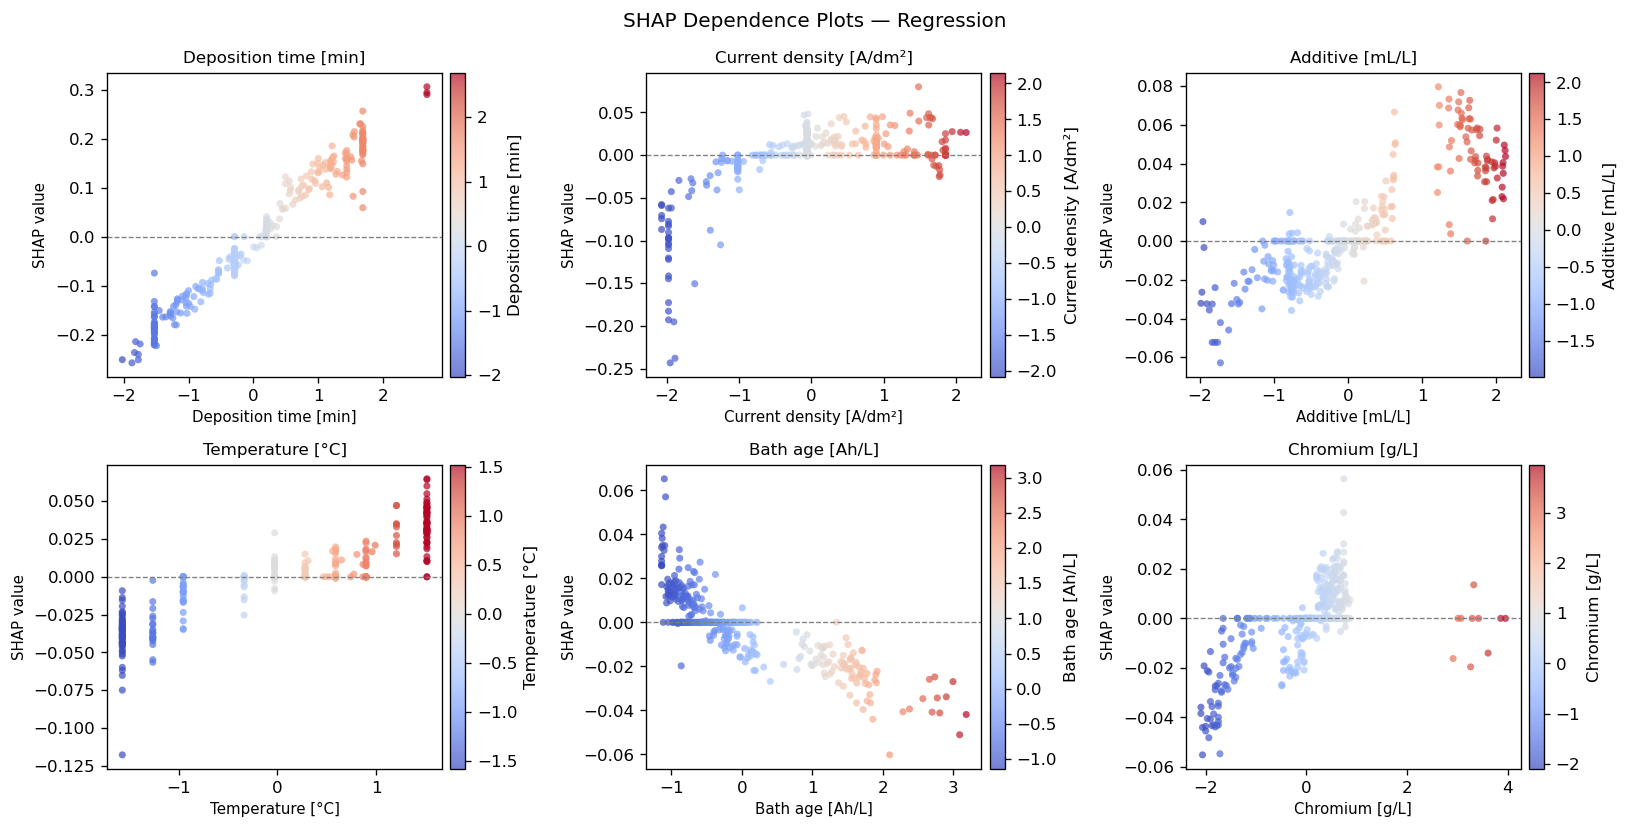

In [53]:
# SHAP dependence plots — Regression
X_train_s_reg = best_predictor_reg_pre.transform(X_train.values)
shap_vals_reg  = xai.compute_shap_values(best_predictor_reg, X_train_s_reg, task="regression")
xai.shap_dependence_plots(
    shap_vals_reg, X_train_s_reg, feature_names,
    top_n=6, task="regression",
)

## 5 · Classification

### 5a · Model Testing — Cross-Validation

In [ ]:
cv_results_path = config.REPORTS_DIR / 'cv_results_reg.csv'
if cv_results_path.exists():
    cv_results = pd.read_csv(cv_results_path)
    print(f"Loaded CV results from {cv_results_path}")
else:
    classifiers = model_testing.get_classifiers()
    print(f'Classifiers: {list(classifiers.keys())}')

    clf_cv = model_testing.evaluate_classifiers(
        X_train, y_train_cls,
        models=classifiers,
        cv_splits=cv_splits
    )
    clf_cv.to_csv(config.REPORTS_DIR / 'cv_results_clf.csv', index=False)

    clf_summary = clf_cv.groupby('model')[['accuracy','f1','auc']].agg(['mean','std']).round(3)
    display(clf_summary.sort_values(('f1','mean'), ascending=False))

Classifiers: ['logistic', 'cart', 'c50', 'gradient_boosting', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'catboost', 'lightgbm', 'mlp', 'tab_cnn', 'ft_transformer', 'saint', 'deep_gbm', 'tabnet']
[model_testing] Evaluating classifier logistic...
[model_testing] Evaluating classifier cart...
[model_testing] Evaluating classifier c50...
[model_testing] Evaluating classifier gradient_boosting...
[model_testing] Evaluating classifier random_forest...
[model_testing] Evaluating classifier extra_trees...
[model_testing] Evaluating classifier hist_gradient_boosting...
[model_testing] Evaluating classifier xgboost...
[model_testing] Evaluating classifier catboost...
[model_testing] Evaluating classifier lightgbm...
[model_testing] Evaluating classifier mlp...
[model_testing] Evaluating classifier tab_cnn...


### 5b · HP Tuning — Classification

Runs twice (original + augmented). Post-HPO F1 picks the winner per classifier.

In [9]:
print("─"*50 + "\nHPO — Classification ORIGINAL\n" + "─"*50)
best_params_clf_orig, scores_clf_orig = hp_tuning.tune_classifiers(
    X_train, y_train_cls, n_trials=100, patience=20,
    save_path=config.REPORTS_DIR / "hp_clf_orig.json",
)

──────────────────────────────────────────────────
HPO — Classification ORIGINAL
──────────────────────────────────────────────────
[hp_tuning] Resuming: 3 done, 13 remaining: ['gradient_boosting', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'catboost', 'lightgbm', 'mlp', 'tab_cnn', 'ft_transformer', 'saint', 'deep_gbm', 'tabnet']
[hp_tuning] Tuning 13 classifiers: ['gradient_boosting', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'catboost', 'lightgbm', 'mlp', 'tab_cnn', 'ft_transformer', 'saint', 'deep_gbm', 'tabnet']
[hp_tuning] Tuning classifier gradient_boosting...
[hp_tuning] gradient_boosting: best F1=0.8530, params={'n_estimators': 209, 'max_depth': 2, 'learning_rate': 0.04515232411240383, 'subsample': 0.5612608098748488, 'min_samples_leaf': 4}
[hp_tuning] Tuning classifier random_forest...
[hp_tuning] random_forest: best F1=0.8396, params={'n_estimators': 425, 'max_depth': 6, 'min_samples_leaf': 2}
[hp_tuning] Tuning classifier 

In [13]:
import importlib
importlib.reload(hp_tuning)  # ensure latest changes are loaded

print("─"*50 + "\nHPO — Classification AUGMENTED (in-fold)\n" + "─"*50)
best_params_clf_aug, scores_clf_aug = hp_tuning.tune_classifiers(
    X_train, y_train_cls, n_trials=100, aug_ratio=0.5, patience=20,
    save_path=config.REPORTS_DIR / "hp_clf_aug.json",
)

──────────────────────────────────────────────────
HPO — Classification AUGMENTED (in-fold)
──────────────────────────────────────────────────
[hp_tuning] Tuning 16 classifiers: ['logistic', 'cart', 'c50', 'gradient_boosting', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'catboost', 'lightgbm', 'mlp', 'tab_cnn', 'ft_transformer', 'saint', 'deep_gbm', 'tabnet']
[hp_tuning] Tuning classifier logistic...
[hp_tuning] logistic: best F1=0.8417, params={'C': 0.2359957768164969}
[hp_tuning] Tuning classifier cart...
[hp_tuning] cart: best F1=0.8214, params={'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 19}
[hp_tuning] Tuning classifier c50...
[hp_tuning] c50: best F1=0.8365, params={'max_depth': 4, 'min_samples_leaf': 6, 'min_samples_split': 8}
[hp_tuning] Tuning classifier gradient_boosting...
[hp_tuning] gradient_boosting: best F1=0.8534, params={'n_estimators': 208, 'max_depth': 6, 'learning_rate': 0.03639245828089606, 'subsample': 0.6391916797480771, 

In [16]:
TOP_ENS = 3
print("─"*50 + "\nModel Ranking — Classification\n" + "─"*50)
ranking_clf, top_models_clf, BEST_CLF, best_params_clf, best_data_source_clf = hp_tuning.rank_models_clf(
    best_params_clf_orig, scores_clf_orig,
    best_params_clf_aug,  scores_clf_aug,
    X_train, y_train_cls, cv_splits, aug_ratio=0.5, top_n=TOP_ENS,
)
display(ranking_clf.round(4))
print(f"\n→ Best classifier: {BEST_CLF}")
print(f"→ Top-{TOP_ENS} for ensemble: {top_models_clf}")

use_aug_clf = best_data_source_clf[BEST_CLF] == "aug"

──────────────────────────────────────────────────
Model Ranking — Classification
──────────────────────────────────────────────────
[rank_clf] gradient_boosting: 0.8534 ± 0.0376  (aug)
[rank_clf] saint: 0.8275 ± 0.0621  (aug)
[rank_clf] hist_gradient_boosting: 0.8662 ± 0.0327  (aug)
[rank_clf] extra_trees: 0.8357 ± 0.0417  (aug)
[rank_clf] Skipping lightgbm: name '_device_kwargs' is not defined
[rank_clf] ft_transformer: 0.8595 ± 0.0179  (orig)
[rank_clf] cart: 0.8447 ± 0.0174  (orig)
[rank_clf] Skipping xgboost: name '_device_kwargs' is not defined
[rank_clf] tab_cnn: 0.8585 ± 0.0256  (orig)
[rank_clf] logistic: 0.8417 ± 0.0373  (aug)
[rank_clf] Skipping catboost: name '_device_kwargs' is not defined
[rank_clf] mlp: 0.8562 ± 0.0378  (orig)
[rank_clf] deep_gbm: 0.8563 ± 0.0338  (aug)
[rank_clf] random_forest: 0.8412 ± 0.0409  (aug)
[rank_clf] c50: 0.8390 ± 0.0239  (orig)
[rank_clf] tabnet: 0.7278 ± 0.0426  (orig)


,model,mean_cv_f1,std_cv_f1,data_source
0,hist_gradient_boosting,0.8662,0.0327,aug
1,ft_transformer,0.8595,0.0179,orig
2,tab_cnn,0.8585,0.0256,orig
3,deep_gbm,0.8563,0.0338,aug
4,mlp,0.8562,0.0378,orig
5,gradient_boosting,0.8534,0.0376,aug
6,cart,0.8447,0.0174,orig
7,logistic,0.8417,0.0373,aug
8,random_forest,0.8412,0.0409,aug
9,c50,0.8390,0.0239,orig



→ Best classifier: hist_gradient_boosting
→ Top-3 for ensemble: ['hist_gradient_boosting', 'ft_transformer', 'tab_cnn']


### 5c · Ensemble — Classification

Top-3 classifiers by post-HPO F1 are trained with their tuned params.  
Strategies: **Averaging** · **Weighted** (by F1) · **Stacking** (LogisticRegression meta-learner)  
Best ensemble saved as `best_predictor_clf` if it outperforms the single final classifier.

In [17]:
print("─"*50 + "\nCV Ensemble Evaluation — Classification\n" + "─"*50)
ens_cv_clf = hp_tuning.cv_eval_ensembles_clf(
    top_models_clf, best_params_clf, best_data_source_clf,
    X_train, y_train_cls, cv_splits, aug_ratio=0.5,
)
display(ens_cv_clf.round(4))
best_ens_clf_name   = ens_cv_clf.iloc[0]["ensemble"]
best_ens_clf_cv_f1  = ens_cv_clf.iloc[0]["mean_cv_f1"]
best_single_cv_f1   = float(ranking_clf[ranking_clf["model"] == BEST_CLF]["mean_cv_f1"].values[0])

print(f"\nBest single   ({BEST_CLF})     CV F1: {best_single_cv_f1:.4f}")
print(f"Best ensemble ({best_ens_clf_name}) CV F1: {best_ens_clf_cv_f1:.4f}")

if best_ens_clf_cv_f1 > best_single_cv_f1:
    winner_clf = f"ensemble:{best_ens_clf_name}"
    print(f"\u2192 Winner (CV): ENSEMBLE ({best_ens_clf_name})")
else:
    winner_clf = f"single:{BEST_CLF}"
    print(f"\u2192 Winner (CV): SINGLE MODEL ({BEST_CLF})")


──────────────────────────────────────────────────
CV Ensemble Evaluation — Classification
──────────────────────────────────────────────────


,ensemble,mean_cv_f1,std_cv_f1
0,averaging,0.8707,0.0282
1,weighted,0.8707,0.0282
2,stacking,0.8672,0.0294



Best single   (hist_gradient_boosting)     CV F1: 0.8662
Best ensemble (averaging) CV F1: 0.8707
→ Winner (CV): ENSEMBLE (averaging)


### 5d · Final Training — Classification

Trains the CV winner (single classifier or ensemble) on the full training set.  
Augmentation applied only if HPO found aug data improved that classifier.  
Test set is touched **once** here for final reporting.


In [ ]:
if winner_clf.startswith("ensemble"):
    print(f"\n→ ENSEMBLE ({best_ens_clf_name}) — training on full data")
    X_final_clf = X_train.copy()
    y_final_clf = y_train_cls.copy()
    pre_ens_clf  = make_preprocessor()
    X_tr_ens_clf = pre_ens_clf.fit_transform(X_final_clf.values)
    base_clf = {}
    for cname in top_models_clf:
        c = _build_classifier(cname, best_params_clf.get(cname, {}))
        c.fit(X_tr_ens_clf, y_final_clf.values)
        base_clf[cname] = c
        print(f"  Trained: {cname}")
    f1_weights   = {c: float(ranking_clf[ranking_clf["model"] == c]["mean_cv_f1"].values[0])
                    for c in top_models_clf}
    avg_ens_clf  = AveragingEnsemble(base_clf, task="classification")
    w_ens_clf    = WeightedEnsemble(base_clf, f1_weights, task="classification")
    stk_ens_clf  = StackingEnsemble(base_clf, task="classification")
    stk_ens_clf.fit(X_tr_ens_clf, y_final_clf.values)
    ensembles_clf           = {"averaging": avg_ens_clf, "weighted": w_ens_clf, "stacking": stk_ens_clf}
    best_predictor_clf      = ensembles_clf[best_ens_clf_name]
    best_predictor_clf_pre  = pre_ens_clf
    best_predictor_clf_type = winner_clf
    use_aug_clf = False

else:
    print(f"\n→ SINGLE CLASSIFIER ({BEST_CLF}) — training on full data")
    use_aug_clf = (best_data_source_clf.get(BEST_CLF) == "aug")
    X_final_tr, y_final_tr = (
        hp_tuning._augment_fold(X_train, y_train_cls, 0.5, perturb_y=False)
        if use_aug_clf else (X_train.copy(), y_train_cls.copy())
    )
    clf_pre   = make_preprocessor()
    clf_model = _build_classifier(BEST_CLF, best_params_clf[BEST_CLF])
    clf_model.fit(clf_pre.fit_transform(X_final_tr.values), y_final_tr.values)
    best_predictor_clf      = clf_model
    best_predictor_clf_pre  = clf_pre
    best_predictor_clf_type = winner_clf

# ── Test set evaluation (never-touched) ────────────────────────────────────────────
y_pred_cls = best_predictor_clf.predict(best_predictor_clf_pre.transform(X_test.values))
try:
    _prob    = best_predictor_clf.predict_proba(best_predictor_clf_pre.transform(X_test.values))[:, 1]
    _auc_val = float(roc_auc_score(y_test_cls, _prob))
except Exception:
    _auc_val = float("nan")
_f1_val  = float(f1_score(y_test_cls, y_pred_cls))
_acc_val = float(accuracy_score(y_test_cls, y_pred_cls))
print(f"\nFINAL TEST ({best_predictor_clf_type}): Acc={_acc_val:.4f}  F1={_f1_val:.4f}  AUC={_auc_val:.4f}")
clf_metrics = {"accuracy": _acc_val, "f1": _f1_val, "auc": _auc_val}

config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "predictor":    best_predictor_clf,
    "preprocessor": best_predictor_clf_pre,
    "type":         best_predictor_clf_type,
    "model_name":   BEST_CLF,
    "threshold":    float(median_threshold),
}, config.MODELS_DIR / "best_predictor_clf.pkl")
print(f"Saved → {config.MODELS_DIR / 'best_predictor_clf.pkl'}")


→ ENSEMBLE (averaging) — training on full data
  Trained: hist_gradient_boosting
  Trained: ft_transformer
  Trained: tab_cnn

FINAL TEST (ensemble:averaging): Acc=0.8955  F1=0.9014  AUC=0.9730
Saved → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/models/best_predictor_clf.pkl


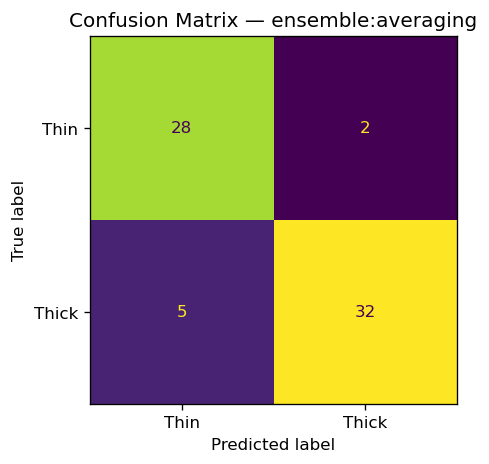

In [29]:
cm = confusion_matrix(y_test_cls, y_pred_cls)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Thin","Thick"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix \u2014 {best_predictor_clf_type}")
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "confusion_matrix.pdf", bbox_inches="tight")
plt.show()

### 5e · XAI — Classification

Uses `best_predictor_clf` (single or ensemble). SHAP · Permutation Importance · ROC


In [30]:
shap_cv_clf = xai.shap_analysis_cv(
    best_predictor_clf, best_predictor_clf_pre,
    X_train, y_train_cls, cv_splits, feature_names, task="classification",
)
shap_imp_clf = shap_cv_clf  # alias for report compatibility
display(shap_imp_clf.head(10))


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

[xai] Saved SHAP-CV → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/shap_cv_clf.pdf


,feature,mean_abs_shap,std_abs_shap
0,Deposition time [min],0.239289,0.014830
1,Additive [mL/L],0.064524,0.010107
2,Temperature [°C],0.054445,0.010246
3,Current density [A/dm²],0.036948,0.013898
4,pH,0.015617,0.001352
5,Chromium [g/L],0.015373,0.003552
6,Copper [mg/L],0.013851,0.001911
7,Bath age [Ah/L],0.010356,0.001582
8,Buffer [g/L],0.010216,0.002196
9,Service life [days],0.009969,0.002280


In [31]:
perm_imp_clf = xai.permutation_importance_cv(
    best_predictor_clf, best_predictor_clf_pre,
    X_train, y_train_cls, cv_splits, feature_names, task="classification", scoring="f1",
)
display(perm_imp_clf.head(10))


[xai] Saved CV permutation importance → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/permutation_importance_cv_clf.pdf


,feature,importance_mean,importance_std
0,Deposition time [min],0.294754,0.058877
1,Additive [mL/L],0.065429,0.023191
2,Current density [A/dm²],0.042299,0.014374
3,Temperature [°C],0.038776,0.018638
4,Complexing agent [mL/L],0.018711,0.015212
5,pH,0.017215,0.021458
6,Copper [mg/L],0.015583,0.009647
7,Chromium [g/L],0.014068,0.009114
8,Bath age [Ah/L],0.012823,0.012447
9,Gloss Nickel layer [%],0.009672,0.007336


  0%|          | 0/374 [00:00<?, ?it/s]

[xai] Saved SHAP dependence plots → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/shap_dependence_classification.pdf


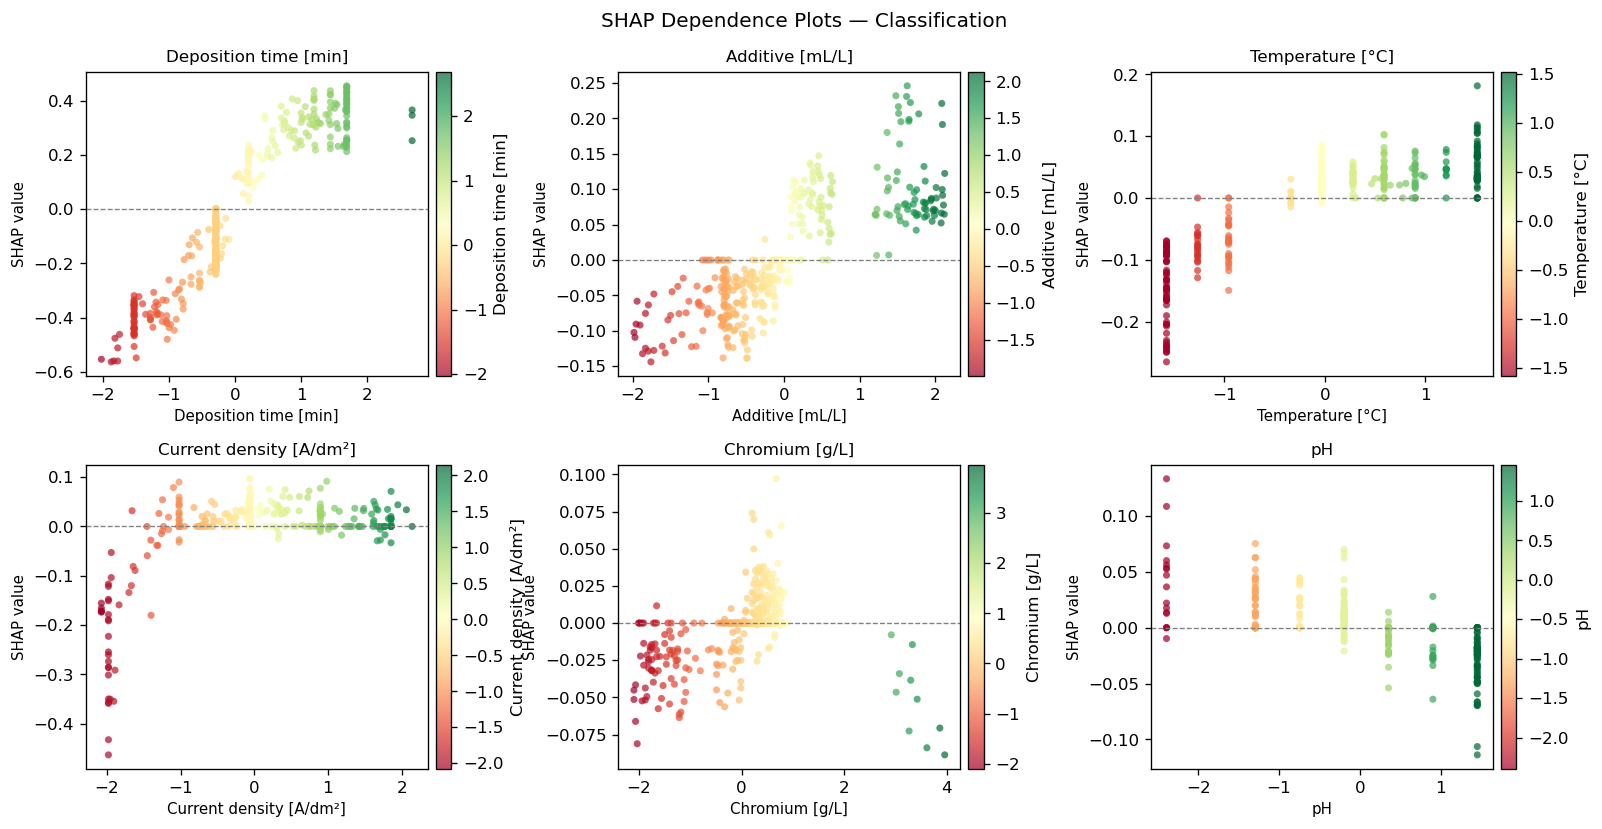

In [32]:
# SHAP dependence plots — Classification
X_train_s_clf = best_predictor_clf_pre.transform(X_train.values)
shap_vals_clf  = xai.compute_shap_values(best_predictor_clf, X_train_s_clf, task="classification")
xai.shap_dependence_plots(
    shap_vals_clf, X_train_s_clf, feature_names,
    top_n=6, task="classification",
)

In [33]:
X_test_best_clf_s = best_predictor_clf_pre.transform(X_test.values)
auc_val = xai.roc_curve_plot(
    best_predictor_clf, X_test_best_clf_s, y_test_cls.values, label=best_predictor_clf_type,
)
print(f"AUC: {auc_val:.4f}")


[xai] Saved ROC curve → /Users/moritzwinklmair/Library/CloudStorage/GoogleDrive-mowi9942@gmail.com/Meine Ablage/work/PhD/DigiChrom/DigiChrom_Pipeline/outputs/figures/roc_curve.pdf  AUC=0.9730
AUC: 0.9730


## 6 · Inverse ML

Uses `best_predictor_reg` from Section 4d for inverse parameter search.


In [54]:
TARGET_THICKNESS = 0.23  # µm
FREE_VARS = ["Deposition time [min]", "Current density [A/dm²]", "Chromium [g/L]", "Buffer [g/L]"]
FIXED_PARAMS = {col: float(X_train[col].median()) for col in feature_names if col not in FREE_VARS}
FREE_BOUNDS  = inverse_ml.get_bounds_from_data(X_train, FREE_VARS)
print('Free variable bounds:')
for v, b in FREE_BOUNDS.items():
    print(f'  {v}: [{b[0]:.2f}, {b[1]:.2f}]')

Free variable bounds:
  Deposition time [min]: [1.00, 20.00]
  Current density [A/dm²]: [2.80, 11.60]
  Chromium [g/L]: [9.59, 11.51]
  Buffer [g/L]: [69.73, 92.87]


In [55]:
solutions = inverse_ml.find_inputs(
    model=best_predictor_reg, preprocessor=best_predictor_reg_pre, feature_names=feature_names,
    fixed_params=FIXED_PARAMS, free_vars=FREE_VARS,
    target_thickness=TARGET_THICKNESS, bounds=FREE_BOUNDS,
    n_solutions=10, method='bayesian', n_trials=100,
)
print(f'\nTop solutions for target = {TARGET_THICKNESS} \u00b5m:')
display(solutions.round(3))


[inverse_ml] Searching for inputs → target=0.23µm, free vars=['Deposition time [min]', 'Current density [A/dm²]', 'Chromium [g/L]', 'Buffer [g/L]'], method=bayesian
[inverse_ml] Top solution: {'Deposition time [min]': 10.49785444608348, 'Current density [A/dm²]': 10.697125906510268, 'Chromium [g/L]': 10.058949544535068, 'Buffer [g/L]': 76.69952526762603, 'predicted_thickness': 0.22962297004787072, 'error': 0.000377029952129293}

Top solutions for target = 0.23 µm:


,Deposition time [min],Current density [A/dm²],Chromium [g/L],Buffer [g/L],predicted_thickness,error
0,10.498,10.697,10.059,76.700,0.230,0.000
1,9.366,6.739,9.785,75.733,0.229,0.001
2,12.256,3.209,10.756,73.676,0.227,0.003
3,9.601,5.792,10.059,79.867,0.226,0.004
4,9.333,6.229,10.122,82.817,0.223,0.007
5,11.375,3.056,10.480,77.362,0.223,0.007
6,9.686,7.134,10.083,83.450,0.237,0.007
7,9.542,6.048,10.132,82.082,0.223,0.007
8,9.418,7.273,10.140,84.592,0.220,0.010
9,9.293,7.274,10.054,86.083,0.220,0.010


## 7 · Comprehensive Report

In [ ]:
print("="*70 + "\nDIGICHROM ML PIPELINE — COMPREHENSIVE REPORT\n" + "="*70)
print(f"\n{'Dataset':─^70}")
print(f"  Total: {len(df)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}  |  Features: {X_train.shape[1]}")
print(f"  Target: {config.TARGET_COL}  |  Range: [{y.min():.3f}, {y.max():.3f}] µm")

In [ ]:
print(f"\n{'Regression':─^70}")

lb = cv_results.groupby('model')[['r2','rmse','mae']].mean().round(4)
display(lb.sort_values('r2', ascending=False))
print(f"  Best single: {BEST_MODEL_REG}  RMSE={metrics_reg['rmse']:.4f}  R²={metrics_reg['r2']:.4f}")
print(f"  best_predictor_reg type: {best_predictor_reg_type}")

In [ ]:
print(f"\n{'Regression Ensemble':─^70}")
display(ens_cv_reg.round(4))

In [ ]:
print(f"\n{'Classification':─^70}")
display(clf_cv.groupby('model')[['accuracy','f1','auc']].mean().round(4).sort_values('f1', ascending=False))
print(f"  Best single: {BEST_CLF}  F1={clf_metrics.get('f1',0):.4f}  AUC={clf_metrics.get('auc',0):.4f}")
print(f"  best_predictor_clf type: {best_predictor_clf_type}")

In [ ]:
print(f"\n{'Classification Ensemble':─^70}")
display(ens_cv_clf.round(4))

In [ ]:
print(f"\n{'Feature Importance — Regression (SHAP)':─^70}")
display(shap_importance.head(10).set_index('feature'))
print(f"\n{'Feature Importance — Classification (SHAP)':─^70}")
display(shap_imp_clf.head(10).set_index('feature'))

In [ ]:
y_pred_r = best_predictor_reg.predict(best_predictor_reg_pre.transform(X_test.values))
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred_r, alpha=0.6, edgecolors='k', linewidths=0.3, s=40)
lims = [min(y_test.min(), y_pred_r.min())*0.95, max(y_test.max(), y_pred_r.max())*1.05]
ax.plot(lims, lims, 'r--', lw=1.5)
ax.set_xlabel('Actual (\u00b5m)'); ax.set_ylabel('Predicted (\u00b5m)')
ax.set_title(f"Predicted vs Actual \u2014 {best_predictor_reg_type}")
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / 'predicted_vs_actual.pdf', bbox_inches='tight')
plt.show()


In [ ]:
report = {
    "regression": {
        "best_model": BEST_MODEL_REG, "used_aug": bool(use_aug_reg),
        "test_metrics": metrics_reg, "best_predictor_type": best_predictor_reg_type,
        "top5_shap": shap_importance.head(5)[['feature','mean_abs_shap']].to_dict(orient='records'),
    },
    "classification": {
        "best_model": BEST_CLF, "threshold_um": float(median_threshold),
        "used_aug": bool(use_aug_clf),
        "test_metrics": {k: float(v) if isinstance(v, float) else v for k, v in clf_metrics.items()},
        "best_predictor_type": best_predictor_clf_type,
        "top5_shap": shap_imp_clf.head(5)[['feature','mean_abs_shap']].to_dict(orient='records'),
    },
}
path = config.REPORTS_DIR / 'comprehensive_report.json'
with open(path, 'w') as f:
    _json.dump(report, f, indent=2)
print(f"Report saved → {path}")
print("="*70)

## 8 PDF Report

In [ ]:
from pipeline import report as _pipeline_report
import importlib
importlib.reload(_pipeline_report)

# Adapt ranking/ensemble DataFrames to report.py column expectations
hpo_reg_for_report = ranking_reg.set_index("model")["mean_cv_rmse"].to_dict()
hpo_clf_for_report = ranking_clf.set_index("model")["mean_cv_f1"].to_dict()
ens_reg_for_report = ens_cv_reg.rename(columns={"mean_cv_rmse": "rmse", "std_cv_rmse": "std"})
ens_clf_for_report = ens_cv_clf.rename(columns={"mean_cv_f1": "f1", "std_cv_f1": "std"})

# Metrics of the best predictor on the test set (single eval reuse from cells 28/47)
X_bp_reg_s  = best_predictor_reg_pre.transform(X_test.values)
y_pred_bp_r = np.atleast_1d(best_predictor_reg.predict(X_bp_reg_s))
metrics_best_pred_reg = {
    "r2":   float(r2_score(y_test, y_pred_bp_r)),
    "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred_bp_r))),
    "mae":  float(mean_absolute_error(y_test, y_pred_bp_r)),
}

X_bp_clf_s  = best_predictor_clf_pre.transform(X_test.values)
y_pred_bp_c = best_predictor_clf.predict(X_bp_clf_s)
y_prob_bp_c = (best_predictor_clf.predict_proba(X_bp_clf_s)[:, 1]
               if hasattr(best_predictor_clf, "predict_proba") else None)
metrics_best_pred_clf = {
    "accuracy": float(accuracy_score(y_test_cls, y_pred_bp_c)),
    "f1":       float(f1_score(y_test_cls, y_pred_bp_c, zero_division=0)),
    "auc":      float(roc_auc_score(y_test_cls, y_prob_bp_c)) if y_prob_bp_c is not None else float("nan"),
}

report_pdf_path = _pipeline_report.generate_report(
    model_name_reg=BEST_MODEL_REG,
    final_model=best_predictor_reg,
    final_pre=best_predictor_reg_pre,
    X_test=X_test,
    y_test=y_test,
    n_train=len(X_train),
    cv_results_reg=cv_results,
    hpo_results_reg=hpo_reg_for_report,
    ensemble_results_reg=ens_reg_for_report,
    metrics_reg=metrics_reg,
    best_predictor_reg_type=best_predictor_reg_type,
    metrics_best_pred_reg=metrics_best_pred_reg,
    shap_importance_reg=shap_importance,
    shap_cv_reg=globals().get("shap_cv_reg"),
    pdp_cv_reg=globals().get("pdp_cv_reg"),
    inverse_ml_solutions=globals().get("solutions"),
    inverse_ml_target=globals().get("TARGET_THICKNESS"),
    clf_name=BEST_CLF,
    clf_model=best_predictor_clf,
    clf_pre=best_predictor_clf_pre,
    y_test_cls=y_test_cls,
    clf_cv=clf_cv,
    hpo_results_clf=hpo_clf_for_report,
    ensemble_results_clf=ens_clf_for_report,
    clf_metrics=clf_metrics,
    best_predictor_clf_type=best_predictor_clf_type,
    metrics_best_pred_clf=metrics_best_pred_clf,
    shap_importance_clf=shap_imp_clf,
    shap_cv_clf=globals().get("shap_cv_clf"),
    pdp_cv_clf=globals().get("pdp_cv_clf"),
    feature_names=feature_names,
    median_threshold=float(median_threshold),
    save_path=config.REPORTS_DIR / "pipeline_report.pdf",
)
print(f"PDF report → {report_pdf_path}")